<a href="https://colab.research.google.com/github/sathu0622/DL_Assigment/blob/feature%2Fabishaan/CNN%20Approch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction**

This project implements a Convolutional Neural Network (CNN) to classify images from the Fashion MNIST dataset — a collection of 70,000 grayscale images of 10 different clothing categories such as shirts, sneakers, and coats.

The CNN model automatically learns visual patterns such as edges, textures, and shapes from raw pixel data, making it well-suited for image recognition tasks.

In this implementation:

* The dataset is preprocessed by normalizing pixel values and reshaping images to fit the CNN input format.

* The model architecture includes multiple convolutional and max-pooling layers to capture spatial hierarchies in the data.

* Fully connected layers are used to perform the final classification across 10 clothing categories.

* The model is trained using the Adam optimizer with the sparse categorical cross-entropy loss function for multi-class classification.

* Finally, the performance of the CNN is evaluated on the test dataset, and accuracy trends are visualized using training and validation metrics.


This approach demonstrates how deep learning can be applied to fashion image classification using TensorFlow and Keras.


# **Import Required Libraries**

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt


# **Load and Preprocess the Dataset**

In [18]:
# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Reshape and normalize data
x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0


# **Build the CNN Model**

In [19]:
model2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# **Compile the Model**

In [20]:
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# **Train the Model**

In [21]:
history2 = model2.fit(
    x_train_cnn, y_train,
    epochs=15,
    validation_data=(x_test_cnn, y_test)
)


Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 34ms/step - accuracy: 0.7756 - loss: 0.6177 - val_accuracy: 0.8720 - val_loss: 0.3533
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.8879 - loss: 0.3065 - val_accuracy: 0.8919 - val_loss: 0.2977
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9065 - loss: 0.2583 - val_accuracy: 0.9011 - val_loss: 0.2760
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 33ms/step - accuracy: 0.9179 - loss: 0.2198 - val_accuracy: 0.9005 - val_loss: 0.2718
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9264 - loss: 0.1951 - val_accuracy: 0.9067 - val_loss: 0.2553
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 33ms/step - accuracy: 0.9357 - loss: 0.1686 - val_accuracy: 0.9113 - val_loss: 0.2508
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9457 - loss: 0.1478 - val_accuracy: 0.9133 - val_loss: 0.2616
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9515 -

# **Evaluate Model Performance**

In [22]:
test_loss, test_acc = model2.evaluate(x_test_cnn, y_test)
print(f"\nFinal Test Accuracy (CNN): {test_acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9038 - loss: 0.4316

Final Test Accuracy (CNN): 0.9072


# **Visualize Training Progress**

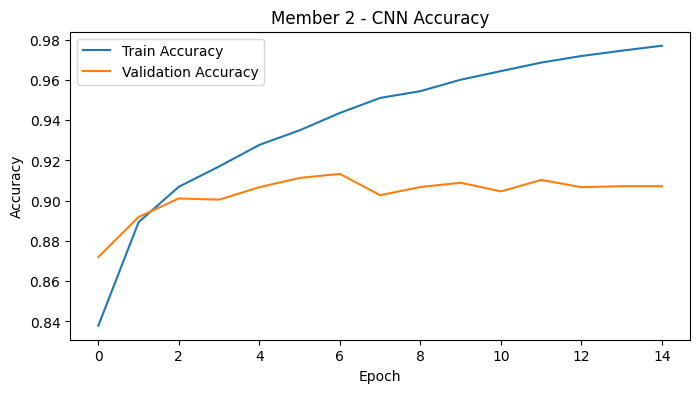

In [23]:
plt.figure(figsize=(8,4))
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title("Member 2 - CNN Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
